# Diagnosing segmentation quality

**Day 1 · Session 2.1**

Segmentation is upstream of everything. If two cells are merged into one, that merged object
gets a gene expression profile, survives normalisation, clusters somewhere, and comes out the
other end looking like a novel intermediate cell state. Nothing downstream will tell you it
is an artifact — it looks exactly like biology.

So before any analysis: **is this segmentation any good?**

### What you will be able to do afterwards

- Compute the metrics that actually diagnose an imaging-based segmentation, following
  the framework in [OSTA](https://lmweber.org/OSTA) and `SpaceTrooper`
- Read each of them **as a spatial map**, not only as a histogram
- Derive thresholds from the distribution rather than from memory
- Choose and defend a filter, and say which cells you just threw away

## Setup

In [1]:
%matplotlib inline

import pathlib
import sys

# Find the repository root (the directory holding paths.py) and make it importable.
# Safe to re-run: unlike %cd, this does not move anywhere.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa: F401

import paths

sdata = sd.read_zarr(paths.data("xenium_breast_2fov.zarr"))
adata = sdata["table"]
adata

no parent found for <ome_zarr.reader.Label object at 0x301b8e180>: None


no parent found for <ome_zarr.reader.Label object at 0x301bae5a0>: None


AnnData object with n_obs × n_vars = 7275 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
    layers: None (.X)

## 1. What the vendor already gave us

Xenium ships per-cell measurements alongside the counts. Several of them are QC metrics that
you would otherwise have to compute yourself.

In [3]:
adata.obs.head()

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
aaaiikim-1,aaaiikim-1,66,0,0,0,0,66,58.477346,34.860626,cell_labels,0.0,1.0,1
aaaljapa-1,aaaljapa-1,95,0,0,0,0,95,77.217190,59.696565,cell_labels,0.0,1.0,2
aabhbgmg-1,aabhbgmg-1,215,0,0,0,0,215,116.187035,73.198284,cell_labels,0.0,1.0,3
aabpgobe-1,aabpgobe-1,103,0,0,0,0,103,71.166253,56.219533,cell_labels,0.0,1.0,4
aacemgol-1,aacemgol-1,95,0,0,0,0,95,99.343754,NaN,cell_labels,0.0,0.0,5


| Column | What it is |
|---|---|
| `transcript_counts` | real gene transcripts assigned to this cell |
| `control_probe_counts` | negative control **probes** — chemistry background |
| `control_codeword_counts` | negative control **codewords** — decoding background |
| `unassigned_codeword_counts` | codewords that decoded to nothing in the panel |
| `total_counts` | the sum of the above |
| `cell_area`, `nucleus_area` | in um^2 |
| `nucleus_count` | how many nuclei the segmentation put inside this cell |

That last one is a gift: a cell with **zero** nuclei or **more than one** is, by definition,
a segmentation that disagrees with itself.

In [4]:
adata.obs["nucleus_count"].value_counts().sort_index()

nucleus_count
0.0     255
1.0    6752
2.0     246
3.0      20
4.0       2
Name: count, dtype: int64

> **_Question:_** Before looking further — should cells with two nuclei be deleted, kept, or
> flagged? Does your answer change if the tissue is tumour rather than normal breast?

## 2. The standard scanpy metrics

`sc.pp.calculate_qc_metrics` works on the table exactly as it would on any scRNA-seq object.

Two things to notice. First, it **overwrites** `total_counts` — same quantity, but recomputed
from `.X` instead of reported by the instrument. Second, and more important:

In [5]:
n_control_features = adata.var_names.str.startswith(
    ("NegControlProbe", "NegControlCodeword", "UnassignedCodeword", "DeprecatedCodeword", "BLANK")
).sum()
print(f"{adata.n_vars} features in the table, of which {n_control_features} are negative controls")

280 features in the table, of which 0 are negative controls


Zero. The table has already been cleaned for you: it holds the 280 real panel genes and
nothing else. The negative controls survive in exactly two places — as the per-cell summary
columns in `.obs`, and as individual rows in the points element.

This is why you cannot do imaging-based QC from the table alone, and why §4 below goes back
to the transcripts.

In [6]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, inplace=True, log1p=False)
adata.obs[["total_counts", "n_genes_by_counts"]].describe()

,total_counts,n_genes_by_counts
count,7275.000000,7275.000000
mean,123.219383,44.646598
std,84.889740,18.243158
min,0.000000,0.000000
25%,54.000000,30.000000
50%,109.000000,46.000000
75%,174.000000,59.000000
max,673.000000,112.000000


## 3. Metric 1 — transcripts per cell

The distribution you always look at first. In imaging-based data the interesting part is the
**low tail**: objects with almost no transcripts are usually debris, fragments at the section
edge, or empty polygons where segmentation fired on nothing.

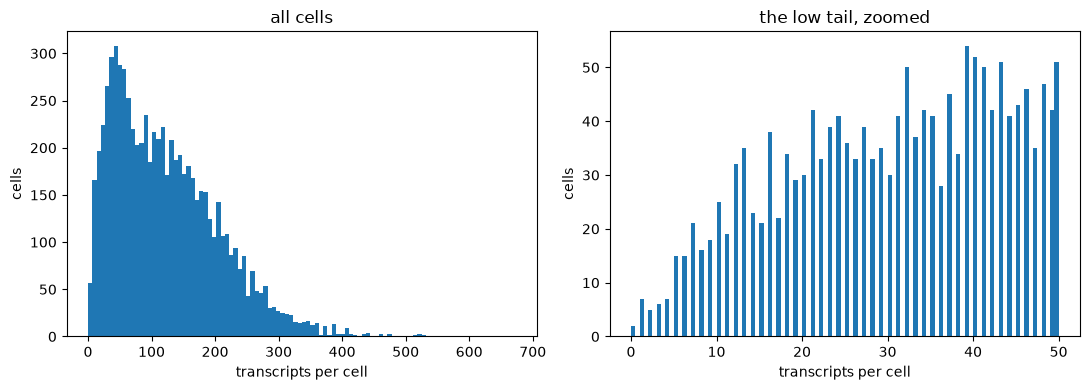

median 109 transcripts per cell
112 cells below 10 transcripts
2 cells with nothing at all


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].hist(adata.obs["total_counts"], bins=100)
axs[0].set(xlabel="transcripts per cell", ylabel="cells", title="all cells")
axs[1].hist(adata.obs["total_counts"], bins=100, range=(0, 50))
axs[1].set(xlabel="transcripts per cell", ylabel="cells", title="the low tail, zoomed")
plt.tight_layout()
plt.show()

print(f"median {adata.obs['total_counts'].median():.0f} transcripts per cell")
print(f"{(adata.obs['total_counts'] < 10).sum()} cells below 10 transcripts")
print(f"{(adata.obs['total_counts'] == 0).sum()} cells with nothing at all")

Now the same quantity **in space**. Remember from Session 1 that the table annotates
`cell_labels`, so that is the element we colour.

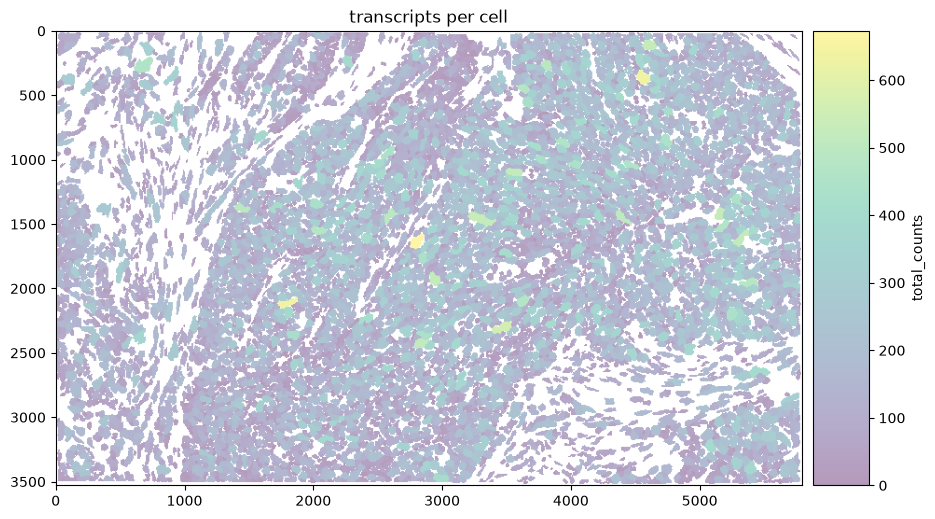

In [8]:
sdata.pl.render_labels("cell_labels", color="total_counts").pl.show(
    coordinate_systems="global", title="transcripts per cell", figsize=(8, 6)
)

## 4. Metric 2 — transcript assignment rate

**If you only ever compute one number, compute this one.**

Every transcript detection either lands inside a cell boundary or it does not. The fraction
that does is the clearest single statement about whether your segmentation is capturing the
tissue. Unassigned transcripts are signal you paid for and cannot use.

This is computed on the *points* element, not the table — the table only ever knew about
transcripts that were successfully assigned.

In [9]:
points = sdata["transcripts"][["cell_id", "qv", "feature_name"]].compute()

cell_id = points["cell_id"].astype(str)
feature = points["feature_name"].astype(str)
is_negative = feature.str.startswith(
    ("NegControlProbe", "NegControlCodeword", "UnassignedCodeword", "DeprecatedCodeword", "BLANK")
)
is_assigned = (cell_id != "UNASSIGNED").to_numpy()
passes_qv = (points["qv"].to_numpy() >= 20)

print(f"transcripts total      {len(points):,}")
print(f"negative controls      {is_negative.sum():,} ({is_negative.mean():.2%})")
print(f"qv >= 20               {passes_qv.mean():.1%}")
print()
print(f"assignment rate, all transcripts        {is_assigned.mean():.1%}")
keep = (~is_negative.to_numpy()) & passes_qv
print(f"assignment rate, real genes at qv >= 20 {is_assigned[keep].mean():.1%}")

transcripts total      1,113,950
negative controls      2,471 (0.22%)
qv >= 20               93.0%

assignment rate, all transcripts        86.5%
assignment rate, real genes at qv >= 20 86.6%


Around 87% here, and the two numbers barely differ — quality filtering does not rescue the
unassigned fraction, which tells you the loss is spatial (transcripts genuinely outside any
boundary) rather than a decoding problem.

There is no universal threshold here — the achievable rate depends on the panel, the tissue,
and how much cytoplasm the segmentation captures. As rough orientation on Xenium-like data,
healthy runs usually land somewhere in the **70–90%** range, and anything below **50%** is a
reason to stop and look at the segmentation before analysing anything. What matters more than
the absolute number is comparing it **between segmentations of the same tissue**, which is
exactly what the next notebook does.

> **_Question:_** Your assignment rate is 70%. Name three different causes — one about
> segmentation, one about chemistry, one about the tissue — and one measurement that would
> distinguish them.

Where the unassigned transcripts *are* matters as much as how many. Diffuse everywhere means
bleed; concentrated in patches means segmentation failed on a specific region or cell type.

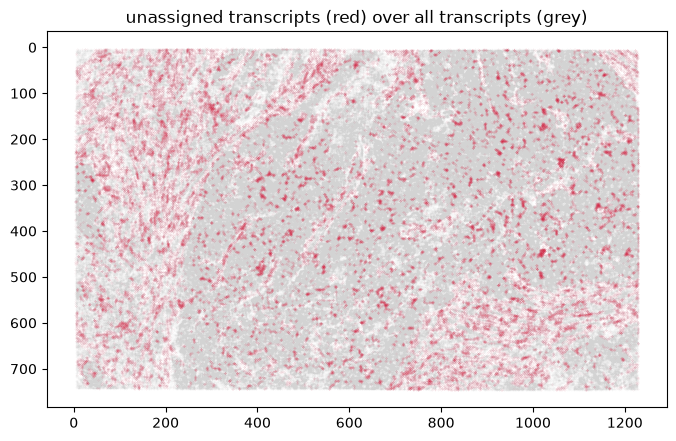

In [10]:
xy = sdata["transcripts"][["x", "y", "cell_id"]].compute()
unassigned = xy[xy["cell_id"].astype(str) == "UNASSIGNED"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(xy["x"], xy["y"], s=0.05, alpha=0.05, color="lightgrey", rasterized=True)
ax.scatter(unassigned["x"], unassigned["y"], s=0.05, alpha=0.08, color="crimson", rasterized=True)
ax.set(title="unassigned transcripts (red) over all transcripts (grey)", aspect="equal")
ax.invert_yaxis()
plt.show()

### Where those transcripts go next: `troutpy`

It is tempting to treat the unassigned fraction as loss and move on. It is also a dataset in
its own right — roughly 150,000 molecules here, each with a position and a gene identity.

[`troutpy`](https://github.com/theislab/troutpy) exists for exactly this. It treats
unassigned RNA (uRNA) as the object of study rather than the residue: which genes are
over-represented outside cells, which cell each molecule most plausibly came from, and
whether a given pattern looks like diffusion or like real extrasomatic organisation.

```python
import troutpy

sdata = troutpy.pp.xenium_converter(...)        # bring a Xenium run into troutpy's layout
troutpy.pp.define_urna(sdata)                   # label transcripts as intra- or extracellular
troutpy.tl.quantify_overexpression(sdata)       # genes enriched outside cells
troutpy.tl.compute_contribution_score(sdata)    # which cell each molecule likely came from
troutpy.tl.assess_diffusion(sdata)              # diffusion, or structured extracellular RNA?
troutpy.pl.intra_extra_density(sdata)
```

<div style="border: 1px solid #4CAF50; border-left-width: 15px; padding: 10px; background-color: #F0FFF0; color: black;">
    <strong>Not installed here.</strong>
    <p>`troutpy` is not part of the course environment, so the block above is a signpost rather
    than something to run today. <code>pip install troutpy</code> on your own machine.</p>
</div>

The reason this matters for QC specifically: a low assignment rate has two very different
explanations, and they call for opposite responses. If the transcripts outside cells are
structured — enriched for particular genes, clustered near particular cell types — then your
segmentation is discarding biology and should be redone. If they are diffuse and gene-agnostic,
that is background, and re-segmenting will not recover it.

Salas et al. (2025), *Exploration of RNA outside segmented cells in spatial transcriptomics
reveals extrasomatic RNA organization*
([doi:10.64898/2025.12.07.692889](https://doi.org/10.64898/2025.12.07.692889))

## 5. Metric 3 — cell area and the nucleus:cell ratio

Area alone catches empty and giant polygons. The **ratio** of nucleus area to cell area is
the more diagnostic quantity:

- ratio near **1** — the segmentation never expanded past the nucleus, so you are measuring
  nuclear transcripts only and losing cytoplasm
- ratio very **low** — the boundary was expanded far past the nucleus and is probably
  swallowing neighbours' transcripts

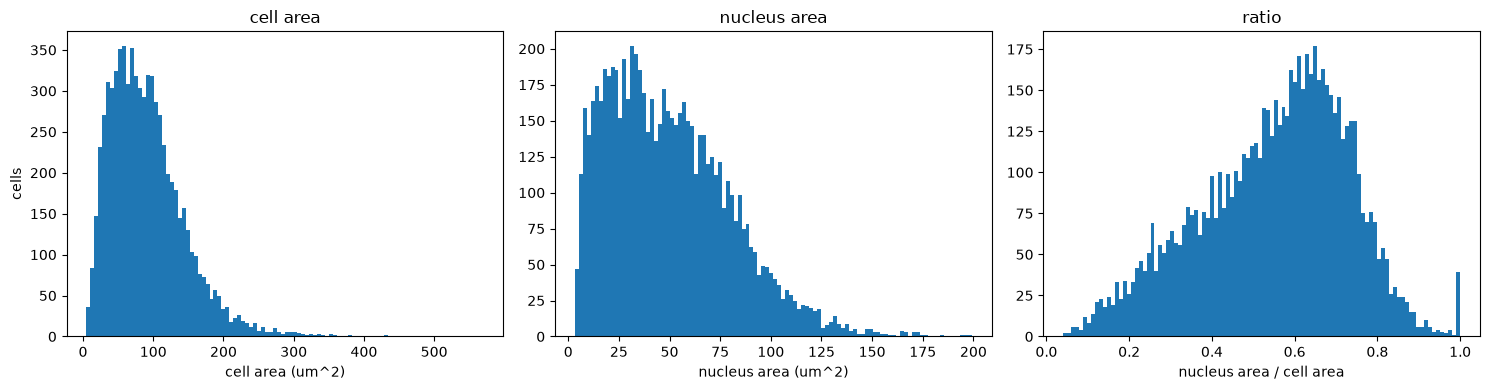

,cell_area,nucleus_area,nucleus_cell_ratio
count,7275.000000,7020.000000,7020.000000
mean,91.268748,49.803306,0.550128
std,53.323052,30.275354,0.179238
min,4.876875,3.251250,0.040554
25%,52.403830,25.547149,0.429209
50%,83.042347,45.878752,0.574919
75%,119.054457,69.247112,0.680901
max,570.142833,199.184226,1.000000


In [11]:
adata.obs["nucleus_cell_ratio"] = adata.obs["nucleus_area"] / adata.obs["cell_area"]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(adata.obs["cell_area"], bins=100)
axs[0].set(xlabel="cell area (um^2)", ylabel="cells", title="cell area")
axs[1].hist(adata.obs["nucleus_area"], bins=100)
axs[1].set(xlabel="nucleus area (um^2)", title="nucleus area")
axs[2].hist(adata.obs["nucleus_cell_ratio"], bins=100)
axs[2].set(xlabel="nucleus area / cell area", title="ratio")
plt.tight_layout()
plt.show()

adata.obs[["cell_area", "nucleus_area", "nucleus_cell_ratio"]].describe()

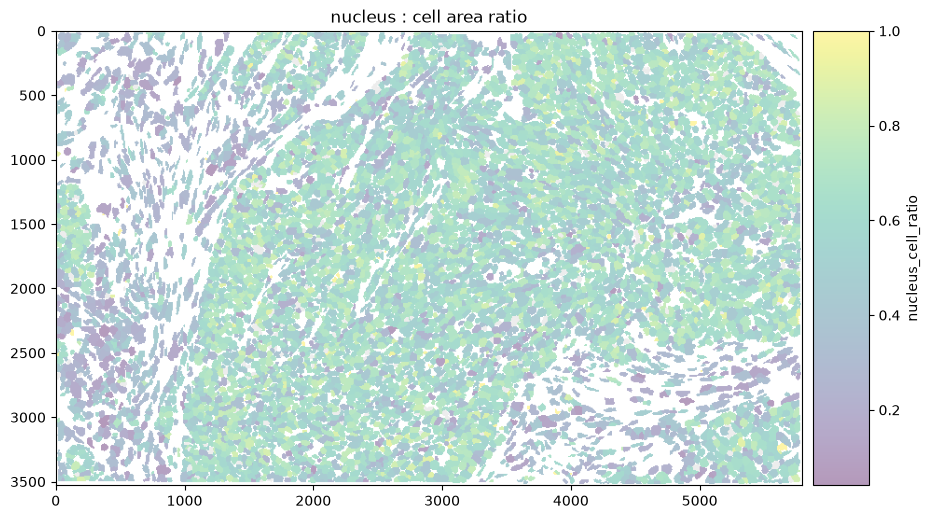

In [12]:
sdata.pl.render_labels("cell_labels", color="nucleus_cell_ratio").pl.show(
    coordinate_systems="global", title="nucleus : cell area ratio", figsize=(8, 6)
)

## 6. Counts versus area — and why the obvious reading is wrong

The instinct is to see a straight line here and call it transcript bleed: bigger polygon,
more background swept up. That instinct is wrong, and it is worth correcting carefully.

Imaging-based ST images a **2D slice through a 3D system**. A bigger slice through a cell
contains more of that cell, so counts and area *should* be related — OSTA makes this point
explicitly. A positive relationship is the expected geometry, not a red flag.

What is diagnostic is **departure** from it: bimodality, or cells sitting far off the trend.
A large cell with very few transcripts is an over-expanded boundary enclosing empty space. A
small cell with very many is probably two cells merged. Those are the ones worth finding, and
they are exactly what the next metric isolates.

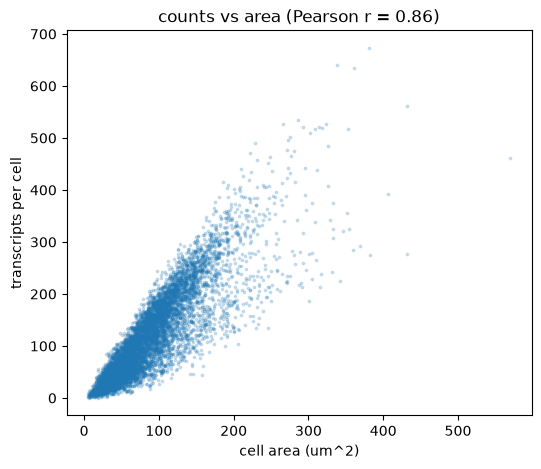

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(adata.obs["cell_area"], adata.obs["total_counts"], s=3, alpha=0.2)
ax.set(xlabel="cell area (um^2)", ylabel="transcripts per cell", title="counts vs area")

r = np.corrcoef(adata.obs["cell_area"], adata.obs["total_counts"])[0, 1]
ax.set_title(f"counts vs area (Pearson r = {r:.2f})")
plt.show()

> **_Question:_** Your counts-vs-area scatter is a clean straight line with r = 0.95. Which
> cells on this plot would you want to look at, and why are they not the ones furthest to the
> right?

## 7. Signal density — counts normalised by geometry

`SpaceTrooper` calls this `SignalDensity`: transcripts per square micron. It is the single
metric that most directly separates the two failure modes above, because it divides out the
geometry that counts-versus-area just told us to expect.

A cell with 40 transcripts is unremarkable. A cell with 40 transcripts spread over 300 um^2
is a boundary enclosing mostly nothing.

count    7275.000000
mean        1.304328
std         0.459581
min         0.000000
25%         0.948215
50%         1.354038
75%         1.661635
max         2.964335
Name: signal_density, dtype: float64


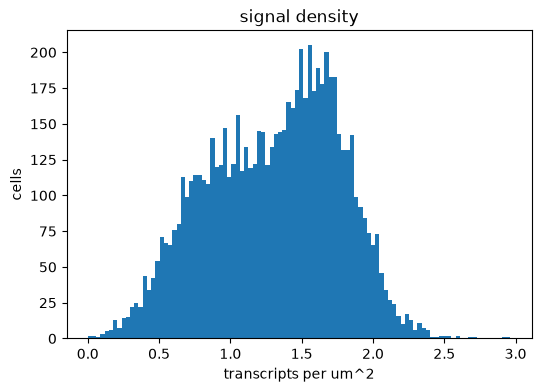

In [14]:
adata.obs["signal_density"] = adata.obs["total_counts"] / adata.obs["cell_area"]

print(adata.obs["signal_density"].describe())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(adata.obs["signal_density"], bins=100)
ax.set(xlabel="transcripts per um^2", ylabel="cells", title="signal density")
plt.show()

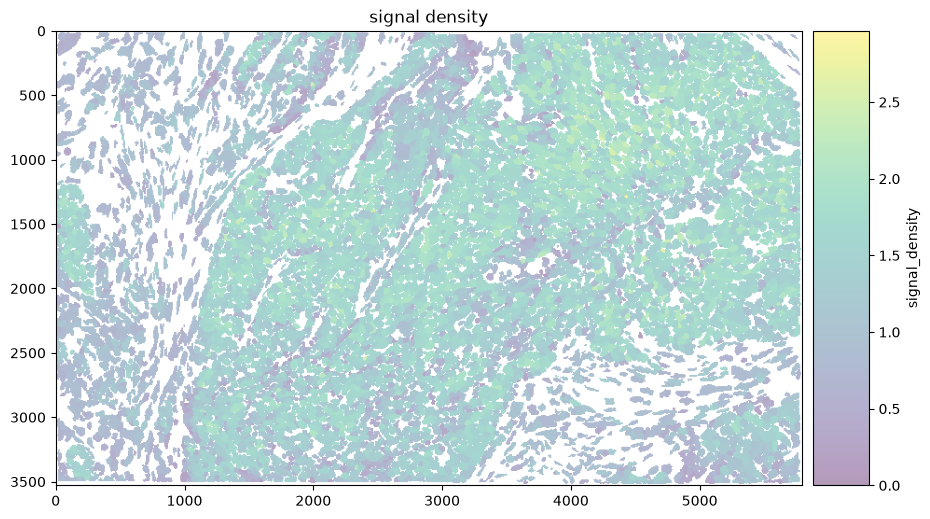

In [15]:
sdata.pl.render_labels("cell_labels", color="signal_density").pl.show(
    coordinate_systems="global", title="signal density", figsize=(8, 6)
)

## 8. Aspect ratio — segmentation errors have a shape

The other `SpaceTrooper` morphology metric. Fit the smallest rotated rectangle around each
cell boundary and take the ratio of its long side to its short side. Real cells are roughly
round to moderately elongated; a boundary that is four or more times longer than it is wide
usually ran along a tissue fibre rather than around a cell.

This is information sequencing-based methods simply do not have. There is no image, so there
is no shape.

In [16]:
import numpy as np


def aspect_ratio(polygon):
    # long side / short side of the minimum rotated rectangle
    x, y = polygon.exterior.coords.xy
    edges = [np.hypot(x[i + 1] - x[i], y[i + 1] - y[i]) for i in range(4)]
    long_side, short_side = max(edges[0], edges[1]), min(edges[0], edges[1])
    return long_side / max(short_side, 1e-9)


boundaries = sdata["cell_boundaries"]
ratios = np.array([aspect_ratio(p) for p in boundaries.geometry.minimum_rotated_rectangle()])
adata.obs["log2_aspect_ratio"] = np.log2(ratios)

elongated = adata.obs["log2_aspect_ratio"] > 2  # more than 4:1
print(f"median log2 aspect ratio {adata.obs['log2_aspect_ratio'].median():.2f}")
print(f"{elongated.sum()} cells are more than 4:1 elongated")

median log2 aspect ratio 0.51
34 cells are more than 4:1 elongated


/home/user1/2026_09_workshop_physalia/.pixi/envs/default/lib/python3.12/site-packages/shapely/constructive.py:1353: RuntimeWarning: divide by zero encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)
/home/user1/2026_09_workshop_physalia/.pixi/envs/default/lib/python3.12/site-packages/shapely/constructive.py:1353: RuntimeWarning: invalid value encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)


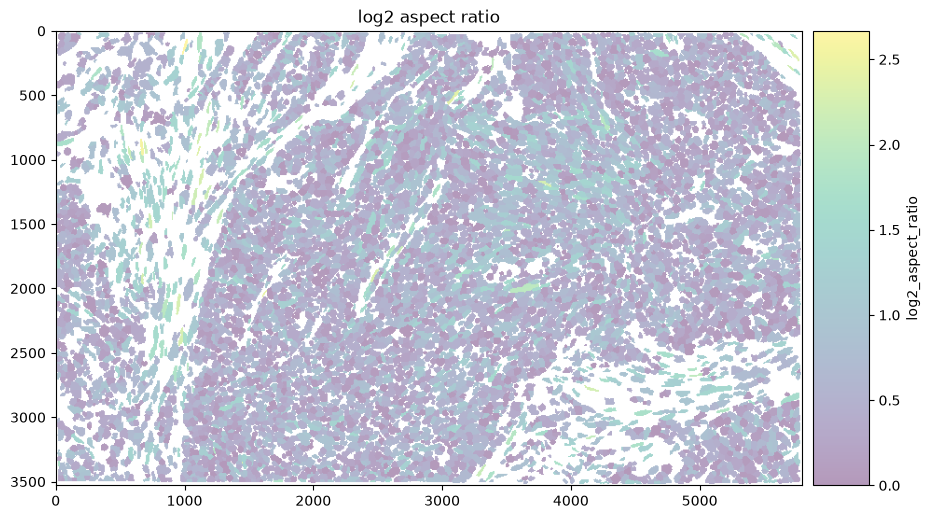

In [17]:
sdata.pl.render_labels("cell_labels", color="log2_aspect_ratio").pl.show(
    coordinate_systems="global", title="log2 aspect ratio", figsize=(8, 6)
)

> **_Question:_** Go and look at the most elongated cells. Are they scattered at random, or do
> they line up? What would each of those two answers mean?

## 9. Metric 5 — negative control rate

Negative control probes and codewords cannot be real signal, so whatever fraction of a cell's
counts they represent is a direct estimate of that cell's background. High background in a
specific region usually means an imaging or tissue problem there, not a biological one.

In [18]:
control_cols = ["control_probe_counts", "control_codeword_counts", "unassigned_codeword_counts"]
adata.obs["control_fraction"] = (
    adata.obs[control_cols].sum(axis=1) / adata.obs["total_counts"].clip(lower=1)
)

print(adata.obs["control_fraction"].describe())
print(f"\ncells above 5% control: {(adata.obs['control_fraction'] > 0.05).sum()}")

count    7275.000000
mean        0.000568
std         0.003519
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.142857
Name: control_fraction, dtype: float64

cells above 5% control: 5


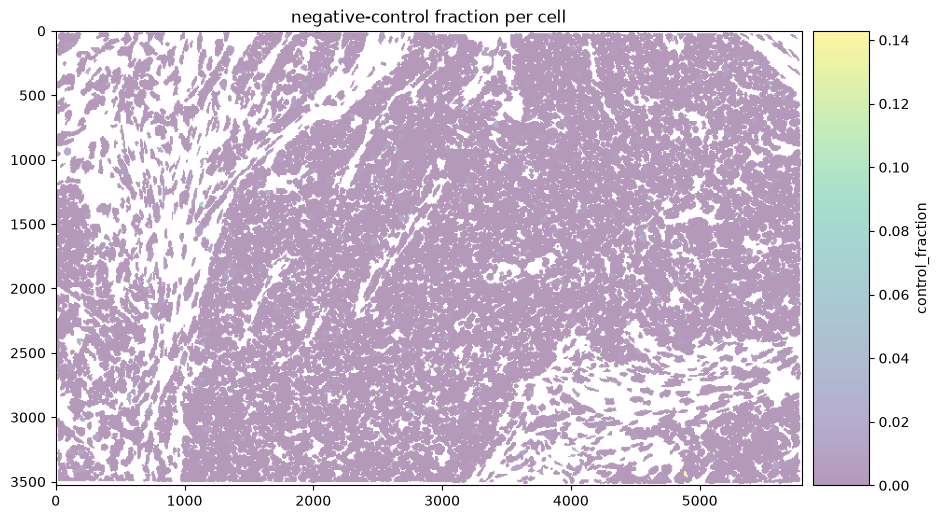

In [19]:
sdata.pl.render_labels("cell_labels", color="control_fraction").pl.show(
    coordinate_systems="global", title="negative-control fraction per cell", figsize=(8, 6)
)

## 10. Fields of view — the artifact you would never guess from a histogram

Imaging platforms acquire a slide in tiles. Each tile is imaged separately, and nothing
guarantees two tiles behave identically — focus, illumination and decoding can all drift
between them. OSTA treats border and field-of-view effects as a first-class failure mode for
exactly this reason.

Our crop is two fields of view, and the transcripts carry which one they came from.

In [20]:
fov = sdata["transcripts"][["fov_name"]].compute()["fov_name"].astype(str)

counts_per_fov = fov.value_counts()
print(counts_per_fov)
print()
print(f"difference: {counts_per_fov.max() / counts_per_fov.min() - 1:.1%}")

fov_name
N14    609953
N13    503997
Name: count, dtype: int64

difference: 21.0%


Two adjacent squares on one slide, and one holds about a fifth more transcripts than the
other.

That difference is either biology — the tissue genuinely differs across that line — or it is
the instrument. **Nothing in the count matrix can tell you which.** You have to go back to the
image and the geometry, which is the entire argument for doing QC before analysis rather than
after a surprising result.

## 11. All of it, in space

This is the point of the session. Each of these metrics has a perfectly unremarkable
histogram. Side by side as spatial maps, structure appears — and **structure is what tells
you an artifact is an artifact**, because real biology and instrument failure look different
in space even when they look identical in a distribution.

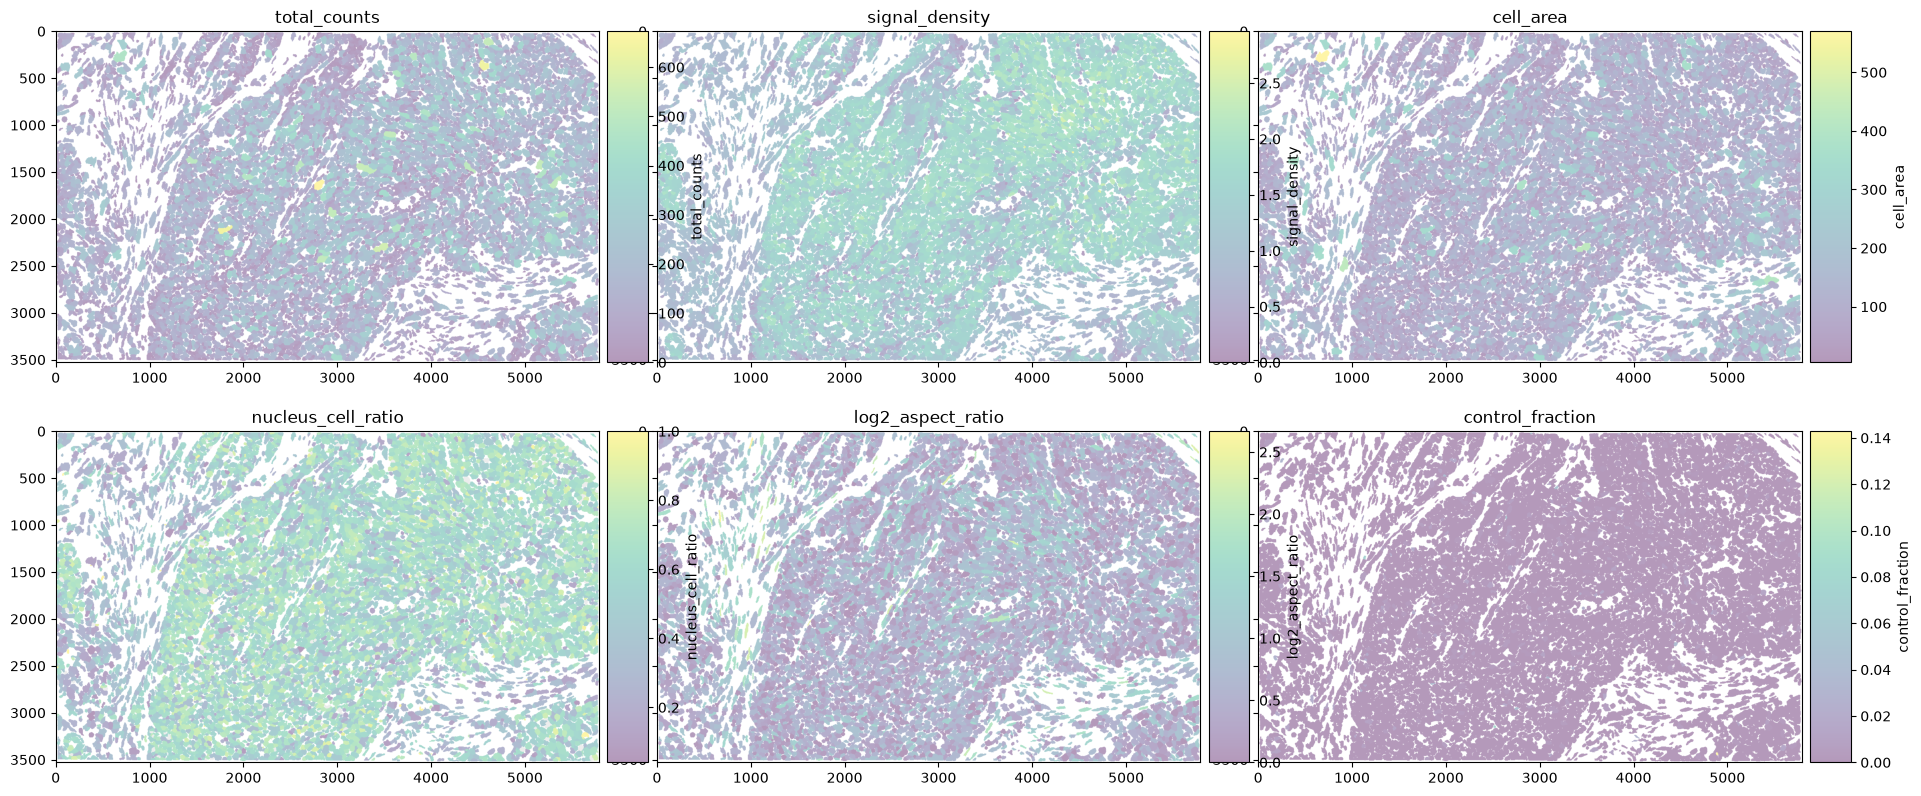

In [21]:
metrics = [
    "total_counts",
    "signal_density",
    "cell_area",
    "nucleus_cell_ratio",
    "log2_aspect_ratio",
    "control_fraction",
]

fig, axs = plt.subplots(2, 3, figsize=(18, 8), layout="constrained")
for ax, metric in zip(axs.flat, metrics):
    sdata.pl.render_labels("cell_labels", color=metric).pl.show(
        coordinate_systems="global", ax=ax, title=metric, colorbar=True
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

## 12. Thresholds from the distribution, not from memory

`total_counts >= 10` is the kind of threshold everyone writes and nobody justifies. It is a
number remembered from a different dataset on a different platform.

OSTA takes the standard approach instead: flag values more than **three median absolute
deviations** from the median, computed on a log scale because these distributions are roughly
log-normal. The threshold then comes from *this* dataset, and it moves when the data moves.

In [22]:
from scipy.stats import median_abs_deviation


def mad_bounds(values, n_mads=3):
    # lower and upper cutoff, n MADs from the median, computed in log space
    logv = np.log1p(values)
    centre, spread = np.median(logv), median_abs_deviation(logv)
    return np.expm1(centre - n_mads * spread), np.expm1(centre + n_mads * spread)


for metric in ["total_counts", "cell_area", "signal_density"]:
    lo, hi = mad_bounds(adata.obs[metric].values)
    flagged = (adata.obs[metric] < lo) | (adata.obs[metric] > hi)
    print(f"{metric:16s} keep [{lo:8.2f}, {hi:8.2f}]  flags {flagged.sum():4d} cells ({flagged.mean():.1%})")

total_counts     keep [   19.69,   583.95]  flags  393 cells (5.4%)
cell_area        keep [   24.13,   280.04]  flags  405 cells (5.6%)
signal_density   keep [    0.52,     2.64]  flags  364 cells (5.0%)


Now the filter, built from those bounds plus the two categorical checks that need no
threshold at all: a cell with no nucleus, and a cell whose signal is mostly negative control.

In [23]:
lo_counts, hi_counts = mad_bounds(adata.obs["total_counts"].values)
lo_density, hi_density = mad_bounds(adata.obs["signal_density"].values)

keep = (
    adata.obs["total_counts"].between(lo_counts, hi_counts)
    & adata.obs["signal_density"].between(lo_density, hi_density)
    & (adata.obs["nucleus_count"] >= 1)
    & (adata.obs["control_fraction"] <= 0.05)
)
adata.obs["qc_pass"] = pd.Categorical(np.where(keep, "pass", "fail"))

print(adata.obs["qc_pass"].value_counts())
print(f"\nremoving {(~keep).sum()} of {len(keep)} cells ({(~keep).mean():.1%})")

qc_pass
pass    6472
fail     803
Name: count, dtype: int64

removing 803 of 7275 cells (11.0%)


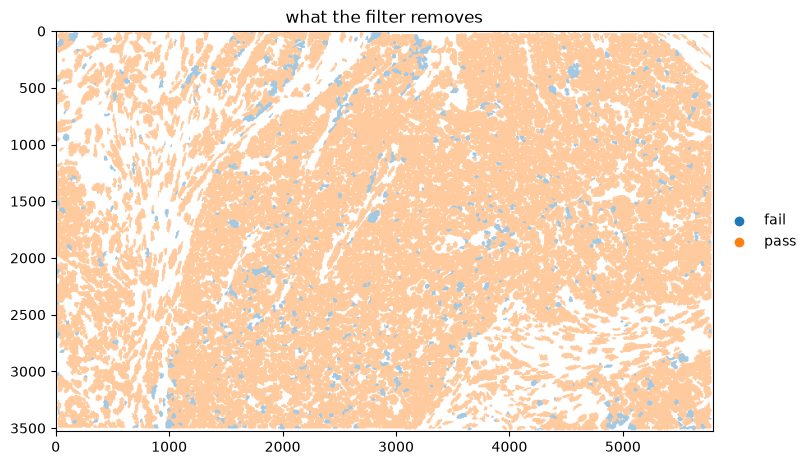

In [24]:
sdata.pl.render_labels("cell_labels", color="qc_pass").pl.show(
    coordinate_systems="global", title="what the filter removes", figsize=(8, 6)
)

In [25]:
# What did we actually delete? Compare the two groups rather than trusting the threshold.
adata.obs.groupby("qc_pass", observed=True)[
    ["total_counts", "signal_density", "cell_area", "nucleus_cell_ratio", "log2_aspect_ratio"]
].median()

,total_counts,signal_density,cell_area,nucleus_cell_ratio,log2_aspect_ratio
qc_pass,,,,,
fail,21.0,0.601775,35.402501,0.542422,0.502512
pass,120.0,1.403309,89.386800,0.578473,0.513550


The filtered object is what Session 3 will build the spatial graph on, so save it to **your**
output directory — the shared data directory is read-only.

In [26]:
adata_qc = adata[keep].copy()
adata_qc.write(paths.OUT / "xenium_qc_filtered.h5ad")
print(f"{adata_qc.n_obs} cells kept -> {paths.OUT / 'xenium_qc_filtered.h5ad'}")

6472 cells kept -> /home/user1/2026_09_workshop_physalia/outputs/xenium_qc_filtered.h5ad


## 13. Global thresholds assume biology is uniform across the slide

Everything above is **global** outlier detection: one distribution for the whole section, one
threshold. It carries an assumption that is safe in dissociated single-cell data and often
false in spatial data — that a cell's QC metrics do not depend on *where it is*.

They do. OSTA's example is brain: grey matter is packed with neuronal cell bodies and white
matter is mostly processes, so grey matter genuinely has a higher library size. A global
threshold does not flag bad spots there; it deletes white matter.

The fix, from the `SpotSweeper` paper, is **local** outlier detection: compare each cell to its
spatial neighbours instead of to the whole slide. We already have everything needed — it is a
spatial graph, which is what Session 3 is about, plus a z-score.

In [27]:
import squidpy as sq

# 36 nearest neighbours: SpotSweeper's default, three rings on a Visium lattice
sq.gr.spatial_neighbors_knn(adata, n_neighs=36)
W = adata.obsp["spatial_connectivities"]

x = np.log1p(adata.obs["total_counts"].values)
degree = np.asarray(W.sum(axis=1)).ravel()
neighbour_mean = (W @ x) / degree
neighbour_var = (W @ x**2) / degree - neighbour_mean**2

adata.obs["local_z"] = (x - neighbour_mean) / np.sqrt(np.maximum(neighbour_var, 1e-12))
adata.obs["local_outlier"] = adata.obs["local_z"] < -3

print(f"{adata.obs['local_outlier'].sum()} cells are outliers relative to their neighbours")

INFO     Creating graph using `None` transform and `1` libraries.                                                  


96 cells are outliers relative to their neighbours


Now compare the two views of the same metric.

In [28]:
global_flag = ~adata.obs["total_counts"].between(lo_counts, hi_counts)
local_flag = adata.obs["local_outlier"]

print(f"global 3-MAD flags          {global_flag.sum():4d}")
print(f"local z < -3 flags          {local_flag.sum():4d}")
print(f"flagged by both             {(global_flag & local_flag).sum():4d}")
print(f"local only, global missed   {(local_flag & ~global_flag).sum():4d}")
print(f"global only, locally normal {(global_flag & ~local_flag).sum():4d}")

global 3-MAD flags           393
local z < -3 flags            96
flagged by both               80
local only, global missed     16
global only, locally normal  313


Read the last line carefully. The large majority of the cells the global threshold would
delete are **entirely unremarkable for where they sit** — they live in a region that is quietly
expressed everywhere, so the whole neighbourhood is low. Deleting them does not remove bad
cells; it removes a tissue compartment.

The handful flagged *only* locally are the opposite case: counts that look acceptable against
the whole slide but are anomalous against their immediate surroundings.

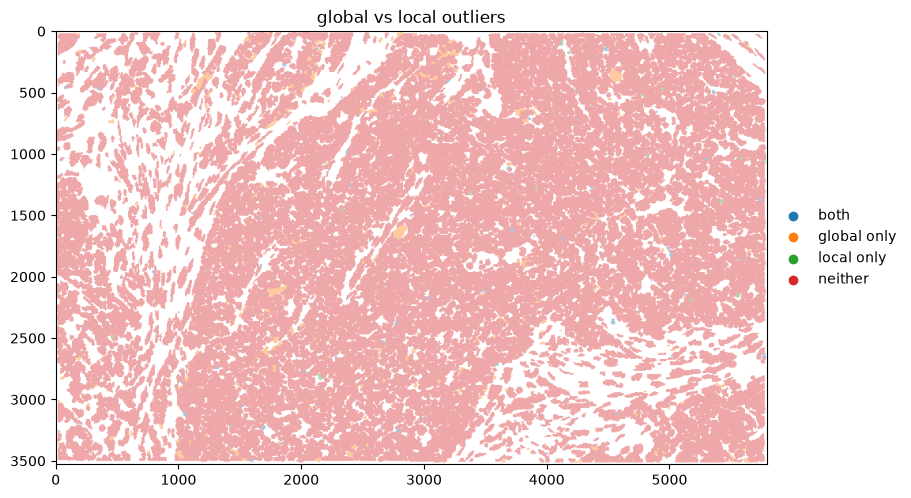

In [29]:
adata.obs["outlier_view"] = pd.Categorical(
    np.where(global_flag & local_flag, "both",
    np.where(global_flag, "global only",
    np.where(local_flag, "local only", "neither")))
)

sdata["table"].obs["outlier_view"] = pd.Categorical(
    adata.obs["outlier_view"].reindex(sdata["table"].obs_names)
)

sdata.pl.render_labels("cell_labels", color="outlier_view").pl.show(
    coordinate_systems="global", title="global vs local outliers", figsize=(9, 6)
)

> **_Question:_** Look at where the "global only" cells sit. Are they scattered, or do they
> form a region? Which of the two filters would you defend to a reviewer, and what would you
> need to check before choosing?

We keep the global filter above for the rest of the course, because it is the one the next
notebooks were built on and because local detection was developed for spot-based data where
neighbourhoods are larger and more uniform. But for a real analysis, this comparison is the
one to run, and the answer is dataset-specific.

Totty et al. (2025), *SpotSweeper: spatially aware quality control for spatial
transcriptomics*, Nature Methods
([doi:10.1038/s41592-025-02713-3](https://doi.org/10.1038/s41592-025-02713-3))

### And if the boundaries themselves are the problem: `sopa`

Everything above diagnoses the segmentation you were handed. None of it fixes one.

[`sopa`](https://gustaveroussy.github.io/sopa/) is the layer that lets you make a different
one without leaving `SpatialData`. It reads the object, tiles the image into patches, runs a
segmentation backend over them, resolves cells cut by tile borders, and aggregates transcripts
onto the new boundaries — writing everything back as ordinary elements.

```python
import sopa

sopa.make_image_patches(sdata, patch_width=1200, patch_overlap=50)
sopa.segmentation.cellpose(sdata, channels=["DAPI"], diameter=33)
sopa.aggregate(sdata, aggregate_genes=True)
```

Backends differ in what they trust: Cellpose segments the image, Baysor and Proseg segment the
transcript positions, and which is right depends on whether your tissue has a usable membrane
stain. `sopa` is installed here, and the next notebook does all of this on one patch and then
re-runs the metrics from this notebook on the result — because the honest version of "is this
segmentation good" is always a comparison.

Blampey et al. (2024), *Sopa: a technology-invariant pipeline for analyses of image-based
spatial omics*, Nature Communications
([doi:10.1038/s41467-024-48981-z](https://doi.org/10.1038/s41467-024-48981-z))

In [30]:
import sopa

print("sopa", sopa.__version__, "- see nb3_segmentation_sopa.ipynb")

sopa 2.2.11 - see nb3_segmentation_sopa.ipynb


### Exercise

1. Change `n_mads` from 3 to 2 and to 5. Plot the removed cells spatially each time. At what
   point do you start deleting a *region* rather than scattered objects?
2. Add a filter on `nucleus_cell_ratio`. Justify both ends of it from the histogram in §5.
3. Compute the median `total_counts` of the cells you removed. If it is not much lower than
   the cells you kept, what does that tell you about your filter?
4. Compare `transcript_counts` (vendor) with `total_counts` (scanpy). Do they agree? If not,
   which features account for the difference?
5. Split any metric by `fov_name` and test whether the two fields of view differ. If they do,
   what would you need in order to decide whether it is biological?

> **_Question:_** Which real cell population did your filter just preferentially delete, and
> how would you notice if it had?

In [31]:
# your answer here

## Pitfalls

- **Do not copy a scRNA-seq QC recipe.** `pct_counts_mt` is meaningless here: there are no
  mitochondrial genes in a 280-gene targeted panel. The negative-control fraction is the
  imaging-based equivalent, and it measures something different.
- **Counts-only filters delete small cells first.** Lymphocytes are small and quiet; an
  aggressive `min_counts` removes immune infiltration and leaves you concluding there was
  none.
- **A histogram cannot show you a bad tissue region.** Always map the metric. Global outlier
  detection treats cells as independent observations and misses local artifacts whose values
  sit comfortably inside the global distribution — this is the argument of the SpotSweeper
  paper, and it is why every metric above is plotted in space.
- **A remembered threshold is not a threshold.** Derive it from the distribution you have.
- **Filtering the table does not filter the elements.** The labels and boundaries still
  contain every object. That is fine — but remember it when you plot.

## Further reading

**The framework this notebook follows**

- [OSTA — *Orchestrating Spatially Resolved Transcriptomics Analysis*](https://lmweber.org/OSTA),
  chapter "Quality control" — the only worked treatment of imaging-based QC we know of, and
  the source of the metric set used here
- Banzi et al. (2025), *SpaceTrooper: a quality control framework for imaging-based spatial
  transcriptomics*, preprint — `SignalDensity`, `log2AspectRatio`, `ctrl_total_ratio`,
  border distance, and a combined quality score
  ([doi:10.64898/2025.12.24.696336](https://doi.org/10.64898/2025.12.24.696336))
- Totty et al. (2025), *SpotSweeper: spatially aware quality control for spatial
  transcriptomics*, Nature Methods — why QC has to be spatial
  ([doi:10.1038/s41592-025-02713-3](https://doi.org/10.1038/s41592-025-02713-3))

**On segmentation and this dataset**

- Petukhov et al. (2022), *Cell segmentation in imaging-based spatial transcriptomics*,
  Nature Biotechnology — the Baysor paper
  ([doi:10.1038/s41587-021-01044-w](https://doi.org/10.1038/s41587-021-01044-w))
- Janesick et al. (2023), *High resolution mapping of the tumor microenvironment*,
  Nature Communications — the study this dataset comes from
  ([doi:10.1038/s41467-023-43458-x](https://doi.org/10.1038/s41467-023-43458-x))
- [10x Xenium algorithms: cell segmentation and QC](https://www.10xgenomics.com/support/software/xenium-onboard-analysis/latest/algorithms-overview)
- [Marconato et al. (2024), *SpatialData*, Nature Methods](https://www.nature.com/articles/s41592-024-02212-x)